# Анализ датасета CoNLL-2003 для задачи NER

Этот ноутбук содержит шаги по загрузке из локальных файлов и первичному анализу датасета CoNLL-2003, который будет использоваться для Выпускной Квалификационной Работы по теме "Исследование и сравнение методов машинного обучения для задачи распознавания именованных сущностей в новостных текстах на английском языке".

## Загрузка датасета CoNLL-2003 из локальных файлов

Датасет CoNLL-2003 представлен в виде текстовых файлов (`eng.train`, `eng.testa`, `eng.testb`) в формате CoNLL, где каждое слово и его метки (включая NER) находятся на отдельной строке, а предложения разделены пустыми строками.

Напишем функцию для парсинга этих файлов.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Функция для парсинга файла в формате CoNLL
def parse_conll_file(filepath):
    sentences = []
    tokens = []
    ner_tags = []
    with open(filepath, 'r', encoding='utf-8') as f:
        for line in f:
            line = line.strip()
            if not line: # Пустая строка - конец предложения
                if tokens: # Добавляем предложение, если оно не пустое
                    sentences.append({'tokens': tokens, 'ner_tags': ner_tags})
                tokens = []
                ner_tags = []
            else:
                # Ожидаем формат: word POS chunk NER
                parts = line.split()
                if len(parts) >= 4: # Убедимся, что строка содержит как минимум 4 колонки
                    tokens.append(parts[0])
                    ner_tags.append(parts[3])
                # Можно добавить обработку ошибок или пропустить некорректные строки
    # Добавляем последнее предложение, если файл не заканчивается пустой строкой
    if tokens:
        sentences.append({'tokens': tokens, 'ner_tags': ner_tags})
    return sentences

# Загрузка данных из локальных файлов
train_data = parse_conll_file('data/eng.train')
val_data = parse_conll_file('data/eng.testa') # В CoNLL-2003 'testa' используется как валидационная выборка
test_data = parse_conll_file('data/eng.testb') # В CoNLL-2003 'testb' используется как тестовая выборка

print(f"Загружено предложений для тренировки: {len(train_data)}")
print(f"Загружено предложений для валидации: {len(val_data)}")
print(f"Загружено предложений для теста: {len(test_data)}")

Загружено предложений для тренировки: 14987
Загружено предложений для валидации: 3466
Загружено предложений для теста: 3684


## Преобразование тегов сущностей в ID

Для обучения моделей необходимо преобразовать строковые метки сущностей (например, 'B-PER', 'O') в числовые идентификаторы (ID).

In [2]:
# Определим список всех уникальных тегов сущностей в CoNLL-2003
# Порядок важен, особенно для тега 'O' (обычно 0)
ner_tag_names = ['O', 'B-PER', 'I-PER', 'B-ORG', 'I-ORG', 'B-LOC', 'I-LOC', 'B-MISC', 'I-MISC']
tag_to_id = {tag: i for i, tag in enumerate(ner_tag_names)}
id_to_tag = {i: tag for tag, i in tag_to_id.items()}

print(f"Список тегов и их ID: {tag_to_id}")

# Функция для преобразования строковых тегов в ID
def map_tags_to_ids(sentences, tag_to_id_map):
    for sentence in sentences:
        # Убедимся, что все теги в данных присутствуют в словаре tag_to_id
        # Если встретится неизвестный тег, это может вызвать ошибку
        sentence['ner_tags_ids'] = [tag_to_id_map[tag] for tag in sentence['ner_tags']]
    return sentences

# Применяем преобразование к загруженным данным
train_data = map_tags_to_ids(train_data, tag_to_id)
val_data = map_tags_to_ids(val_data, tag_to_id)
test_data = map_tags_to_ids(test_data, tag_to_id)

print("\nПример записи после преобразования тегов в ID:")
print(train_data[0])

Список тегов и их ID: {'O': 0, 'B-PER': 1, 'I-PER': 2, 'B-ORG': 3, 'I-ORG': 4, 'B-LOC': 5, 'I-LOC': 6, 'B-MISC': 7, 'I-MISC': 8}

Пример записи после преобразования тегов в ID:
{'tokens': ['-DOCSTART-'], 'ner_tags': ['O'], 'ner_tags_ids': [0]}


## Первичный анализ данных (продолжение)

Теперь, когда данные загружены и теги преобразованы, проведем анализ количества токенов и распределения типов сущностей.

In [3]:
# Количество токенов в каждой выборке
train_tokens = sum(len(s['tokens']) for s in train_data)
val_tokens = sum(len(s['tokens']) for s in val_data)
test_tokens = sum(len(s['tokens']) for s in test_data)

print(f"\nКоличество токенов в тренировочной выборке: {train_tokens}")
print(f"Количество токенов в валидационной выборке: {val_tokens}")
print(f"Количество токенов в тестовой выборке: {test_tokens}")


Количество токенов в тренировочной выборке: 204567
Количество токенов в валидационной выборке: 51578
Количество токенов в тестовой выборке: 46666



Распределение типов именованных сущностей (без тега 'O'):
B-LOC     10645
B-PER     10059
B-ORG      9323
I-PER      6991
I-ORG      5290
B-MISC     5062
I-MISC     1717
I-LOC      1671
Name: count, dtype: int64


C:\Users\79103\AppData\Local\Temp\ipykernel_6988\1684833048.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=tag_counts.index, y=tag_counts.values, palette='viridis')


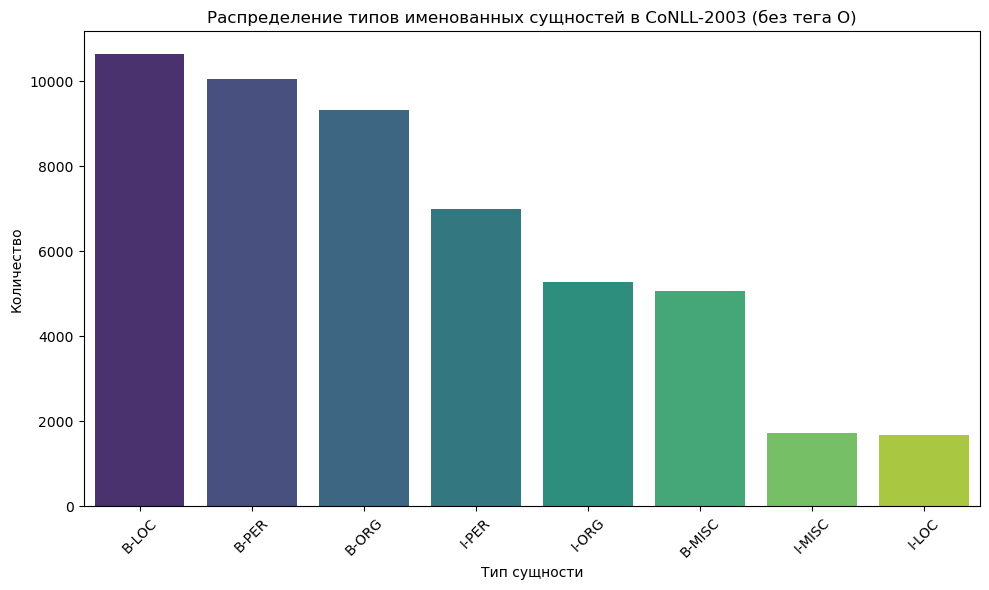

In [4]:
# Распределение типов именованных сущностей (без тега 'O')
all_ner_tags_ids = []
for dataset_split in [train_data, val_data, test_data]:
    for sentence in dataset_split:
        # Исключаем тег 'O' (ID 0)
        all_ner_tags_ids.extend([tag_id for tag_id in sentence['ner_tags_ids'] if tag_id != 0])

# Преобразуем ID обратно в строковые метки для подсчета и визуализации
all_ner_tags_names = [id_to_tag[tag_id] for tag_id in all_ner_tags_ids]

tag_counts = pd.Series(all_ner_tags_names).value_counts()

print("\nРаспределение типов именованных сущностей (без тега 'O'):")
print(tag_counts)

# Визуализация распределения
plt.figure(figsize=(10, 6))
sns.barplot(x=tag_counts.index, y=tag_counts.values, palette='viridis')
plt.title('Распределение типов именованных сущностей в CoNLL-2003 (без тега O)')
plt.xlabel('Тип сущности')
plt.ylabel('Количество')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Углубленный разведочный анализ данных (EDA)

Проведем дополнительный анализ, чтобы лучше понять характеристики датасета, которые могут повлиять на выбор и производительность моделей.

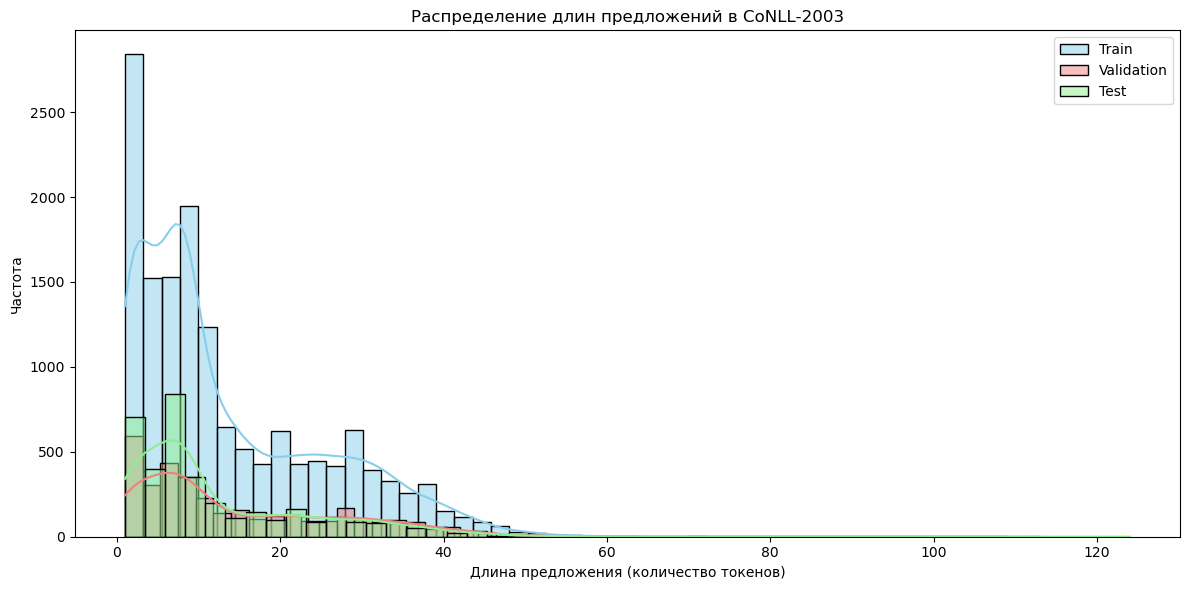


Средняя длина предложения (Train): 13.65
Медианная длина предложения (Train): 9.00
Максимальная длина предложения (Train): 113


In [5]:
# Анализ распределения длин предложений
train_sentence_lengths = [len(s['tokens']) for s in train_data]
val_sentence_lengths = [len(s['tokens']) for s in val_data]
test_sentence_lengths = [len(s['tokens']) for s in test_data]

plt.figure(figsize=(12, 6))
sns.histplot(train_sentence_lengths, bins=50, kde=True, color='skyblue', label='Train')
sns.histplot(val_sentence_lengths, bins=50, kde=True, color='lightcoral', label='Validation')
sns.histplot(test_sentence_lengths, bins=50, kde=True, color='lightgreen', label='Test')
plt.title('Распределение длин предложений в CoNLL-2003')
plt.xlabel('Длина предложения (количество токенов)')
plt.ylabel('Частота')
plt.legend()
plt.tight_layout()
plt.show()

print(f"\nСредняя длина предложения (Train): {np.mean(train_sentence_lengths):.2f}")
print(f"Медианная длина предложения (Train): {np.median(train_sentence_lengths):.2f}")
print(f"Максимальная длина предложения (Train): {np.max(train_sentence_lengths)}")

In [6]:
# Анализ частоты встречаемости токенов (опционально, может быть ресурсоемким для больших датасетов)
# from collections import Counter
# all_tokens = []
# for dataset_split in [train_data, val_data, test_data]:
#     for sentence in dataset_split:
#         all_tokens.extend(sentence['tokens'])

# token_counts = Counter(all_tokens)
# print("\nТоп-20 самых частых токенов:")
# print(token_counts.most_common(20))

## Дальнейшая предобработка и выбор методов

На основе проведенного анализа данных можно сделать выводы о необходимых шагах дальнейшей предобработки и сформулировать гипотезы о наиболее подходящих моделях для задачи NER на этом датасете.

**Необходимые шаги предобработки:**

*   **Векторизация токенов:** Преобразование текстовых токенов в числовые векторы, которые могут быть использованы моделями МО. Это может включать:
    *   Использование предобученных векторных представлений слов (Word Embeddings) типа GloVe или Word2Vec.
    *   Использование контекстуализированных эмбеддингов из трансформерных моделей (например, BERT, RoBERTa).
*   **Padding/Truncation:** Приведение всех последовательностей токенов и тегов к одинаковой длине для пакетной обработки моделями, особенно нейронными сетями.

**Гипотезы о методах МО для NER:**

Учитывая последовательную природу задачи NER и характеристики датасета CoNLL-2003, перспективными методами являются:

*   **Conditional Random Fields (CRF):** Классический статистический метод, хорошо подходящий для задач разметки последовательностей. Эффективен, но может требовать ручного создания признаков.
*   **Рекуррентные нейронные сети (RNN) с LSTM/GRU и CRF слоем:** Модели, способные обрабатывать последовательности и учитывать контекст. Добавление CRF слоя на выходной слой часто улучшает качество, учитывая зависимости между соседними тегами.
*   **Модели на основе трансформеров (BERT, RoBERTa и др.):** Современные модели, которые используют механизм внимания для улавливания долгосрочных зависимостей в тексте и предоставляют мощные контекстуализированные эмбеддинги. Fine-tuning таких моделей на задаче NER часто дает наилучшие результаты.

В рамках ВКР планируется реализовать и сравнить несколько из этих подходов, чтобы оценить их эффективность на датасете CoNLL-2003.

## Выводы по первичному анализу

*(После выполнения кода выше, здесь будут суммированы основные характеристики датасета: размеры выборок, общее количество токенов и предложений, а также выявленные особенности распределения сущностей. Например, какие типы сущностей встречаются чаще всего, есть ли сильный дисбаланс между типами.)*

Полученные данные готовы для дальнейшей предобработки (например, векторизации токенов) и использования в моделях машинного обучения.

In [ ]:
MAX_SEQ_LENGTH = 128
PAD_TOKEN = "[PAD]" # Специальный токен для паддинга
PAD_TAG_ID = tag_to_id['O'] # Используем ID тега 'O' для паддинга тегов

def pad_and_truncate_sequence(sequence, max_length, pad_value):
    """Паддинг или усечение последовательности до max_length."""
    if len(sequence) > max_length:
        return sequence[:max_length]
    elif len(sequence) < max_length:
        return sequence + [pad_value] * (max_length - len(sequence))
    return sequence

def preprocess_for_padding(sentences, max_length, pad_token, pad_tag_id):
    """Применяет паддинг и усечение к токенам и тегам."""
    processed_sentences = []
    for sentence in sentences:
        padded_tokens = pad_and_truncate_sequence(sentence['tokens'], max_length, pad_token)
        padded_tags_ids = pad_and_truncate_sequence(sentence['ner_tags_ids'], max_length, pad_tag_id)
        processed_sentences.append({
            'tokens': padded_tokens,
            'ner_tags_ids': padded_tags_ids,
            'original_length': len(sentence['tokens']) # Сохраняем оригинальную длину
        })
    return processed_sentences

# Применяем паддинг и усечение к данным
train_data_padded = preprocess_for_padding(train_data, MAX_SEQ_LENGTH, PAD_TOKEN, PAD_TAG_ID)
val_data_padded = preprocess_for_padding(val_data, MAX_SEQ_LENGTH, PAD_TOKEN, PAD_TAG_ID)
test_data_padded = preprocess_for_padding(test_data, MAX_SEQ_LENGTH, PAD_TOKEN, PAD_TAG_ID)
